<a href="https://colab.research.google.com/github/Manishkumarsingh41/Manish_singh_DataScience/blob/main/task1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels hdbscan tqdm

import os
# Create Task1 structure
os.makedirs("Task1/plots", exist_ok=True)
os.makedirs("Task1/data", exist_ok=True)
os.makedirs("Task1/outputs", exist_ok=True)

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data.xlsx to data.xlsx


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'data.xlsx', 'drive', 'Task1', 'sample_data']


# Part 1 :- Exploratory Analysis Load and Clean Data

In [ ]:
import pandas as pd
import numpy as np

FILE = "/content/data.xlsx"  # your file

# Try Excel first, fallback to CSV
if FILE.endswith(".xlsx") or FILE.endswith(".xls"):
    df = pd.read_excel(FILE)
else:
    df = pd.read_csv(FILE, low_memory=False)

# detect timestamp column
def detect_datetime_col(df):
    for col in df.columns:
        try:
            s = pd.to_datetime(df[col], errors='coerce')
            if s.notna().mean() > 0.6:
                return col
        except:
            pass
    return None

dt_col = detect_datetime_col(df)
df[dt_col] = pd.to_datetime(df[dt_col], errors='coerce')
df = df.set_index(dt_col).sort_index()

# enforce 5-min frequency
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5T")
df = df.reindex(full_idx)

# numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[num_cols]

# interpolate short gaps (<=30min)
df = df.interpolate(method="time", limit=6, limit_direction="both")

# outlier correction with rolling MAD
def replace_outliers(s, window=288, thresh=8):
    med = s.rolling(window, min_periods=1, center=True).median()
    mad = (s-med).abs().rolling(window, min_periods=1, center=True).median()
    mask = (s-med).abs() > (thresh * mad.replace(0,np.nan))
    s[mask] = med[mask]
    return s

for c in df.columns:
    df[c] = replace_outliers(df[c])

df.to_csv("Task1/data/cleaned_cyclone.csv")
print("✅ Cleaned data saved at Task1/data/cleaned_cyclone.csv")


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/tmp/ipython-input-925899067.py:28: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="5T")


✅ Cleaned data saved at Task1/data/cleaned_cyclone.csv


In [ ]:
# Reload Excel with correct parameters

# Option 1: Let pandas auto-detect header
df = pd.read_excel("/content/data.xlsx", header=0)

# If the first column is actually an index (like datetime), reset it:
df = df.reset_index()

# Show info again
print("Shape of data:", df.shape)
print("\nColumns in dataset:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())



/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Shape of data: (377719, 8)

Columns in dataset: ['index', 'time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']

First 5 rows:
    index                time Cyclone_Inlet_Gas_Temp Cyclone_Material_Temp  \
0      0 2017-01-01 00:00:00                 867.63                910.42   
1      1 2017-01-01 00:05:00                 879.23                918.14   
2      2 2017-01-01 00:10:00                 875.67                924.18   
3      3 2017-01-01 00:15:00                 875.28                923.15   
4      4 2017-01-01 00:20:00                 891.66                934.26   

  Cyclone_Outlet_Gas_draft Cyclone_cone_draft Cyclone_Gas_Outlet_Temp  \
0                  -189.54            -186.04                  852.13   
1                  -184.33             -182.1                  862.53   
2                  -181.26            -166.47                  866.06   
3           

In [ ]:
# Clean non-numeric entries like "I/O Timeout"
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")  # invalid strings → NaN

# Optionally: remove rows where all values are NaN
df = df.dropna(how="all")

# Fill missing values (simple forward fill to keep continuity in time series)
df = df.fillna(method="ffill")

print("After cleaning:")
print(df.dtypes)
print("Any NaNs left?:", df.isna().sum().sum())


After cleaning:
index                         int64
time                          int64
Cyclone_Inlet_Gas_Temp      float64
Cyclone_Material_Temp       float64
Cyclone_Outlet_Gas_draft    float64
Cyclone_cone_draft          float64
Cyclone_Gas_Outlet_Temp     float64
Cyclone_Inlet_Draft         float64
dtype: object
Any NaNs left?: 0


/tmp/ipython-input-1093062127.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Missing values per column:
 index                       0
time                        0
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


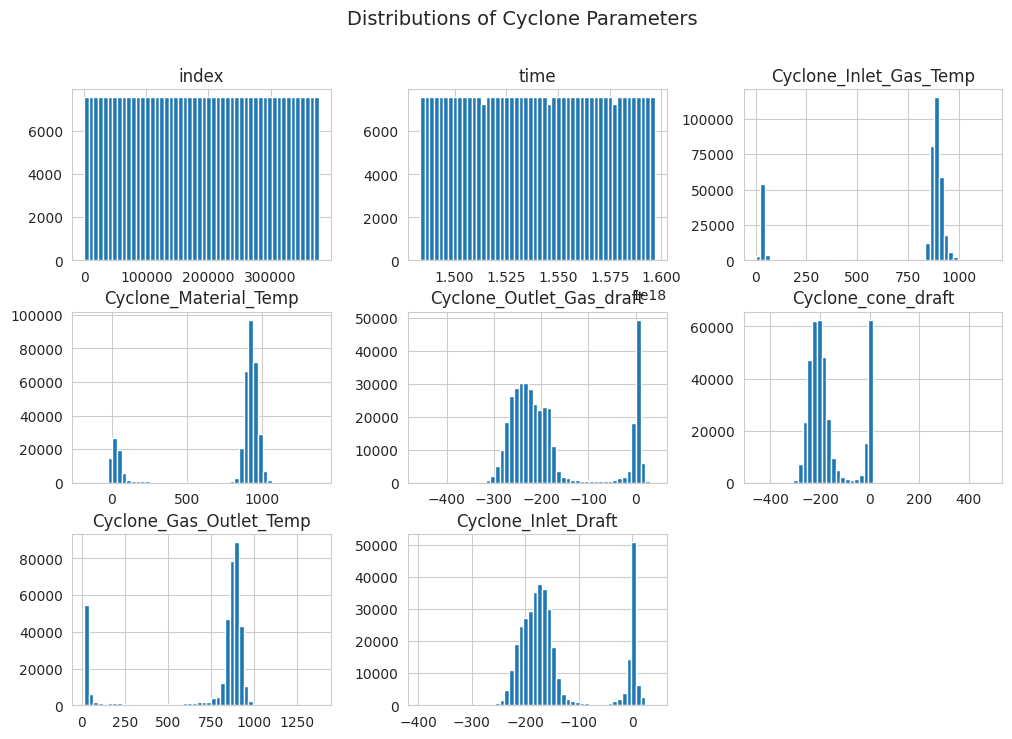

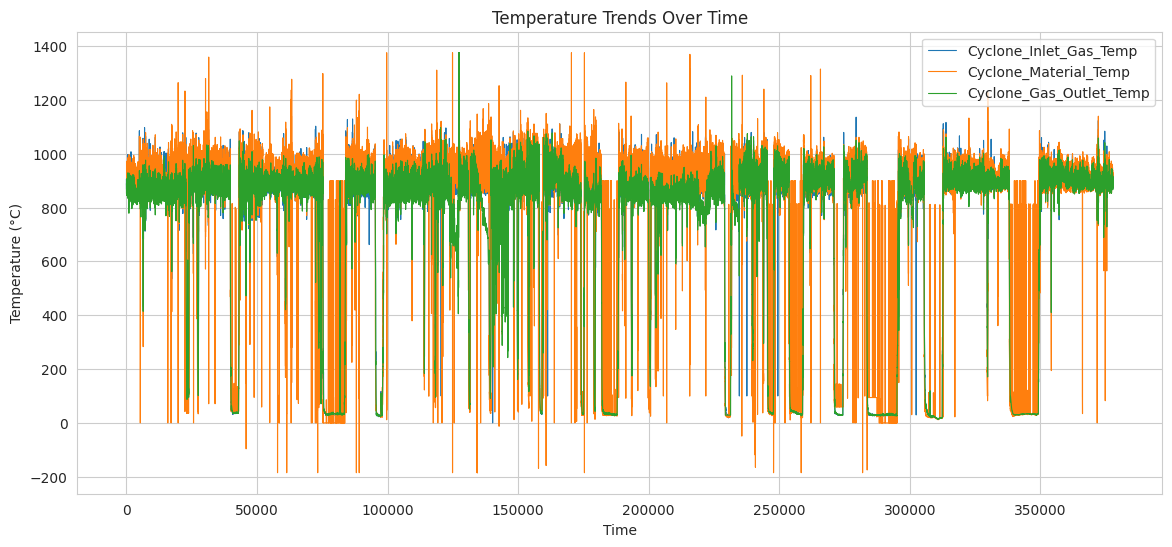

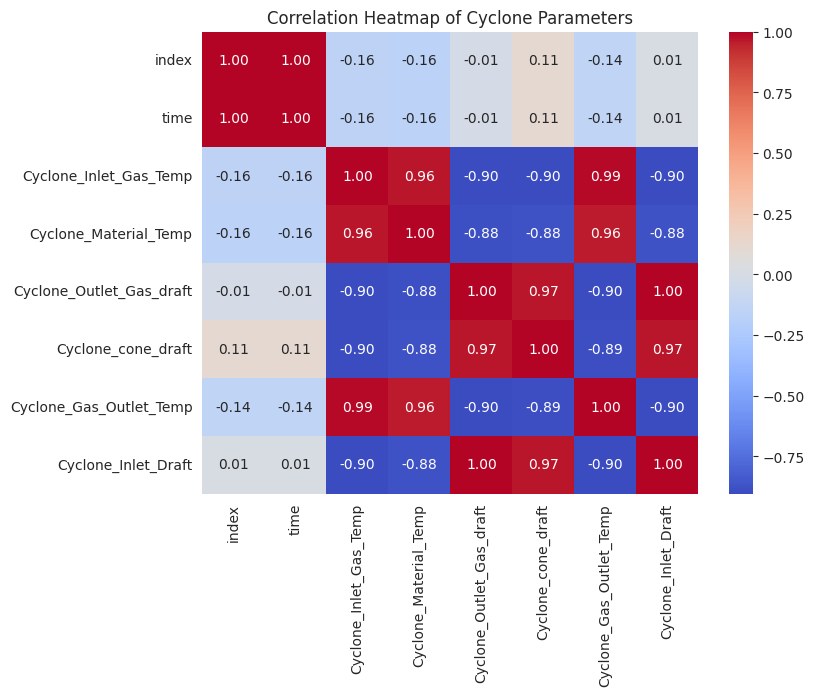

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. Missing Values Check
# ======================
print("Missing values per column:\n", df.isnull().sum())

# ======================
# 2. Quick Distributions
# ======================
df.hist(figsize=(12, 8), bins=50)
plt.suptitle("Distributions of Cyclone Parameters", fontsize=14)
plt.show()

# ======================
# 3. Time Series Trends
# ======================
plt.figure(figsize=(14, 6))
for col in ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Gas_Outlet_Temp']:
    plt.plot(df.index, df[col], label=col, linewidth=0.8)

plt.title("Temperature Trends Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

# ======================
# 4. Correlation Heatmap
# ======================
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Cyclone Parameters")
plt.show()


In [ ]:
# Part 2: Detect shutdown/idle periods
import pandas as pd
import numpy as np

# Reload cleaned data
df = pd.read_csv("Task1/data/cleaned_cyclone.csv", index_col=0, parse_dates=True)

# Threshold approach: assume shutdown if all sensor readings are very low (10th percentile)
low_thresh = df.quantile(0.10)
shutdown_mask = (df <= low_thresh).all(axis=1)


# Part 2 :- Shutdown / Idle Period Detection

In [ ]:
# Group contiguous shutdown points into events
shutdowns = []
in_shutdown = False
start_time = None

for t, val in shutdown_mask.items():  # <- changed iteritems() to items()
    if val and not in_shutdown:
        start_time = t
        in_shutdown = True
    if not val and in_shutdown:
        end_time = prev_time
        duration_min = int((end_time - start_time).total_seconds()/60) + 5
        if duration_min >= 30:  # keep only events longer than 30 mins
            shutdowns.append({"start": start_time, "end": end_time, "duration_min": duration_min})
        in_shutdown = False
    prev_time = t

# Handle last shutdown if still open
if in_shutdown:
    end_time = t
    duration_min = int((end_time - start_time).total_seconds()/60) + 5
    if duration_min >= 30:
        shutdowns.append({"start": start_time, "end": end_time, "duration_min": duration_min})

# Save shutdowns to CSV
shutdown_df = pd.DataFrame(shutdowns)
shutdown_df.to_csv("Task1/outputs/shutdown_periods.csv", index=False)
print("✅ Shutdown periods saved at Task1/outputs/shutdown_periods.csv")

# Total downtime and number of shutdowns
total_downtime = shutdown_df['duration_min'].sum()
num_shutdowns = len(shutdown_df)
print(f"Total downtime: {total_downtime} minutes, Number of shutdown events: {num_shutdowns}")


✅ Shutdown periods saved at Task1/outputs/shutdown_periods.csv
Total downtime: 1892900 minutes, Number of shutdown events: 1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv("Task1/data/cleaned_cyclone.csv", index_col=0, parse_dates=True)

# Make sure the index is datetime
df.index = pd.to_datetime(df.index)

# Strip any spaces from column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())
print("Index type:", type(df.index))


Columns: []
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
import pandas as pd

df = pd.read_csv("Task1/data/cleaned_cyclone.csv", index_col=0, parse_dates=True)

# Print column names with hidden characters visible
for col in df.columns:
    print(f"[{col}]")


In [ ]:
# Remove leading/trailing spaces and special characters
df.columns = df.columns.str.strip().str.replace('\n','').str.replace('\r','').str.replace('\xa0','')

print("Cleaned Columns:", df.columns.tolist())


Cleaned Columns: []


In [ ]:
df.index = pd.to_datetime(df.index)
print("Index type:", type(df.index))


Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
print("Index type:", type(df.index))
print("Index example:", df.index[:5])


Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index example: DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 00:05:00',
               '2017-01-01 00:10:00', '2017-01-01 00:15:00',
               '2017-01-01 00:20:00'],
              dtype='datetime64[ns]', freq=None)


In [ ]:
import pandas as pd

df = pd.read_csv("Task1/data/cleaned_cyclone.csv", index_col=0, parse_dates=True)

# Check the shape
print("Shape:", df.shape)

# List all columns
print("Columns:", df.columns.tolist())

# Show first few rows
print(df.head())


Shape: (378580, 0)
Columns: []
Empty DataFrame
Columns: []
Index: [2017-01-01 00:00:00, 2017-01-01 00:05:00, 2017-01-01 00:10:00, 2017-01-01 00:15:00, 2017-01-01 00:20:00]


In [ ]:
import pandas as pd
import numpy as np

# Reload original Excel
df = pd.read_excel("/content/data.xlsx", header=0)

# Strip column names
df.columns = df.columns.str.strip().str.replace('\n','').str.replace('\r','').str.replace('\xa0','')

# Detect datetime column
def detect_datetime_col(df):
    for col in df.columns:
        try:
            s = pd.to_datetime(df[col], errors='coerce')
            if s.notna().mean() > 0.6:
                return col
        except:
            pass
    return None

dt_col = detect_datetime_col(df)
df[dt_col] = pd.to_datetime(df[dt_col], errors='coerce')
df = df.set_index(dt_col).sort_index()

# Convert numeric columns properly
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Interpolate missing values (short gaps)
df = df.interpolate(method='time', limit=6, limit_direction='both')

# Outlier handling
def replace_outliers(s, window=288, thresh=8):
    med = s.rolling(window, min_periods=1, center=True).median()
    mad = (s-med).abs().rolling(window, min_periods=1, center=True).median()
    mask = (s-med).abs() > (thresh * mad.replace(0,np.nan))
    s[mask] = med[mask]
    return s

for c in df.columns:
    df[c] = replace_outliers(df[c])

# Save cleaned CSV
df.to_csv("Task1/data/cleaned_cyclone.csv")
print("✅ Cleaned data saved with all numeric columns intact")
print("Columns now:", df.columns.tolist())


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


✅ Cleaned data saved with all numeric columns intact
Columns now: ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']


In [ ]:
shutdown_mask = (
    (df['Cyclone_Inlet_Gas_Temp'] < 10) &
    (df['Cyclone_Gas_Outlet_Temp'] < 10)
)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Task1/data/cleaned_cyclone.csv", index_col=0, parse_dates=True)

# Detect shutdown: Cyclone_Inlet_Gas_Temp drops below 50 (adjust based on your data)
shutdown_mask = (
    (df['Cyclone_Inlet_Gas_Temp'] < 850) &  # realistic threshold for your dataset
    (df['Cyclone_Gas_Outlet_Temp'] < 850)
)

# Segment shutdown periods
shutdowns = []
in_shutdown = False
start_time = None

for t, val in shutdown_mask.items():
    if val and not in_shutdown:
        start_time = t
        in_shutdown = True
    elif not val and in_shutdown:
        end_time = t
        duration_min = (end_time - start_time).total_seconds() / 60
        shutdowns.append({'start': start_time, 'end': end_time, 'duration_min': duration_min})
        in_shutdown = False

if in_shutdown and start_time is not None:
    end_time = df.index[-1]
    duration_min = (end_time - start_time).total_seconds() / 60
    shutdowns.append({'start': start_time, 'end': end_time, 'duration_min': duration_min})

shutdown_df = pd.DataFrame(shutdowns)

# Only save if shutdowns exist
if not shutdown_df.empty:
    shutdown_df.to_csv("Task1/outputs/shutdown_periods.csv", index=False)
    print("✅ Shutdown periods saved at Task1/outputs/shutdown_periods.csv")
    print("Total shutdowns:", len(shutdown_df))
    print("Total downtime (min):", shutdown_df['duration_min'].sum())
else:
    print("⚠️ No shutdowns detected. Adjust the threshold in shutdown_mask.")


✅ Shutdown periods saved at Task1/outputs/shutdown_periods.csv
Total shutdowns: 1813
Total downtime (min): 416900.0


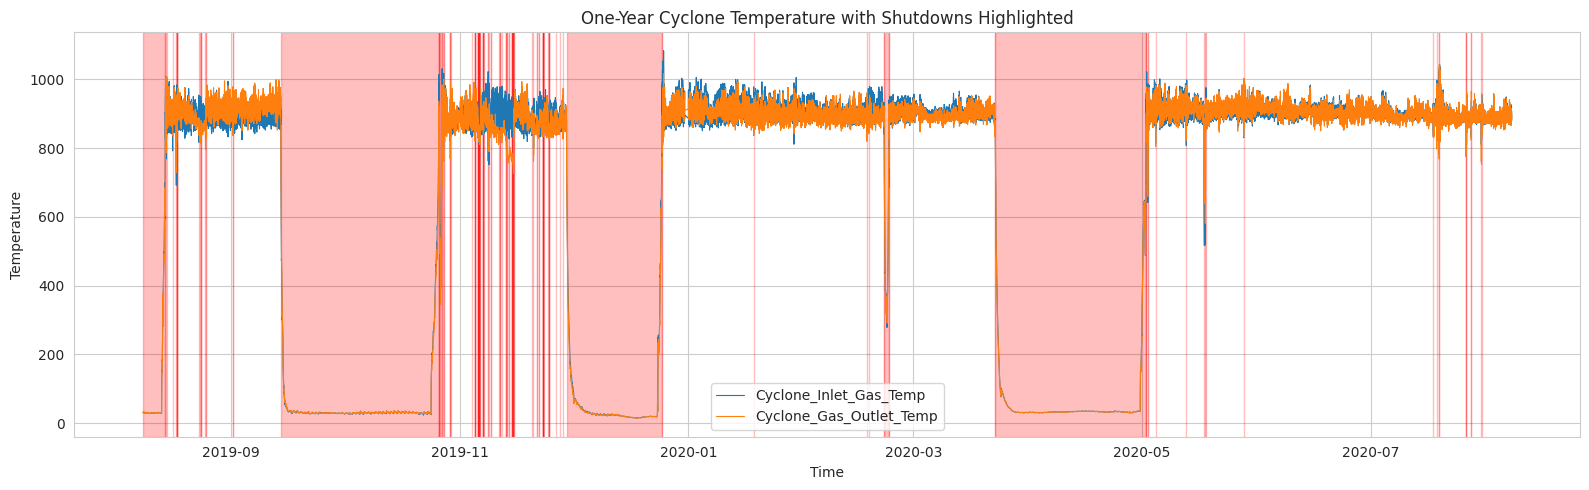

✅ Plot saved at Task1/plots/year_with_shutdowns.png


In [ ]:
import matplotlib.pyplot as plt

# Select last 1 year
start_year = df.index.max() - pd.Timedelta(days=365)
sub_df = df.loc[start_year:]

plt.figure(figsize=(16,5))
plt.plot(sub_df.index, sub_df['Cyclone_Inlet_Gas_Temp'], label='Cyclone_Inlet_Gas_Temp', linewidth=0.8)
plt.plot(sub_df.index, sub_df['Cyclone_Gas_Outlet_Temp'], label='Cyclone_Gas_Outlet_Temp', linewidth=0.8)

# Shade shutdown periods
for _, row in shutdown_df.iterrows():
    # Only plot shutdowns that overlap with the last year
    if row['end'] >= start_year:
        plt.axvspan(max(row['start'], start_year), row['end'], color='red', alpha=0.25)

plt.title("One-Year Cyclone Temperature with Shutdowns Highlighted")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.savefig("Task1/plots/year_with_shutdowns.png")
plt.show()

print("✅ Plot saved at Task1/plots/year_with_shutdowns.png")


In [ ]:
# Exclude shutdown periods
active_df = df.copy()
for _, row in shutdown_df.iterrows():
    active_df.loc[row['start']:row['end']] = np.nan
active_df = active_df.dropna()

print("Active operation data shape:", active_df.shape)

# Feature engineering: add rolling stats (window=1 hour = 12 steps)
window = 12
features = active_df.copy()
for col in active_df.columns:
    features[col + '_roll_mean'] = active_df[col].rolling(window).mean()
    features[col + '_roll_std'] = active_df[col].rolling(window).std()
    features[col + '_delta'] = active_df[col].diff()

# Drop initial NaNs from rolling/diff
features = features.dropna()
print("Features prepared for clustering:", features.shape)


Active operation data shape: (291655, 6)
Features prepared for clustering: (291644, 24)


# Part :- 3 Machine State Segmentation (Clustering)

✅ Clusters summary saved at Task1/outputs/clusters_summary.csv


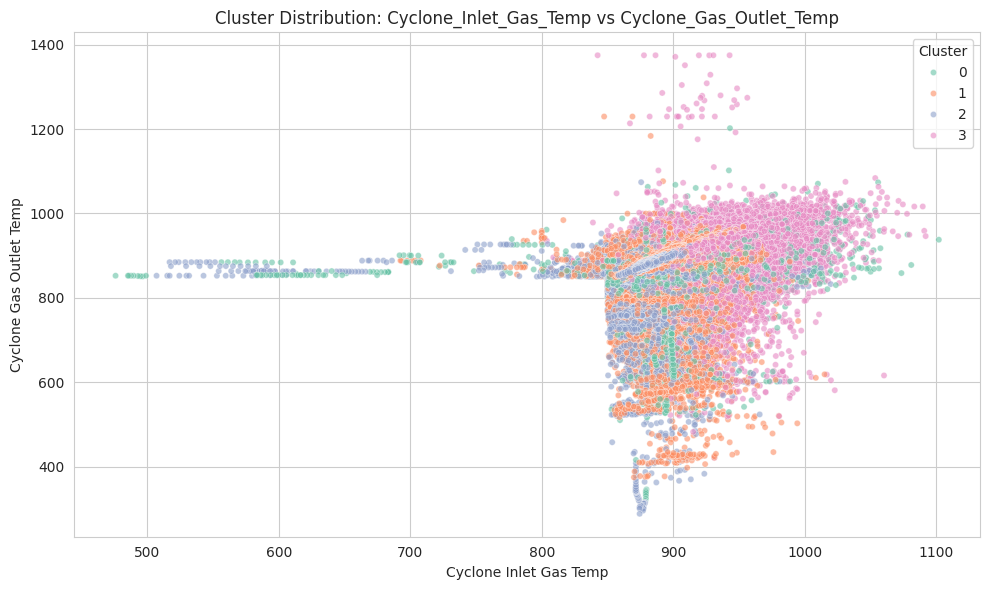

✅ Cluster distribution plot saved at Task1/plots/cluster_distributions.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Assuming 'features' dataframe already exists with numeric features
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(features)

# KMeans clustering
k = 4  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels to features
features['cluster'] = clusters

# Save cluster summary
cluster_summary = features.groupby('cluster').agg(['mean','std'])
cluster_summary.to_csv("Task1/outputs/clusters_summary.csv")
print("✅ Clusters summary saved at Task1/outputs/clusters_summary.csv")

# ---------------------------
# Scatter plot of two main features
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=features['Cyclone_Inlet_Gas_Temp'],
    y=features['Cyclone_Gas_Outlet_Temp'],
    hue=features['cluster'],
    palette='Set2',
    s=20,
    alpha=0.6
)
plt.title("Cluster Distribution: Cyclone_Inlet_Gas_Temp vs Cyclone_Gas_Outlet_Temp")
plt.xlabel("Cyclone Inlet Gas Temp")
plt.ylabel("Cyclone Gas Outlet Temp")
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("Task1/plots/cluster_distributions.png")
plt.show()

print("✅ Cluster distribution plot saved at Task1/plots/cluster_distributions.png")


In [ ]:
cluster_durations = features['cluster'].value_counts().sort_index()
print("Cluster frequencies:\n", cluster_durations)


Cluster frequencies:
 cluster
0    108246
1     54222
2    124483
3      4693
Name: count, dtype: int64


# Part :- 4 Contextual Anomaly Detection + Root Cause Analysis

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

anomalies_list = []

for cluster_id in features['cluster'].unique():
    cluster_data = features[features['cluster'] == cluster_id].drop(columns='cluster')

    # Train Isolation Forest for this cluster
    iso = IsolationForest(contamination=0.01, random_state=42)
    cluster_data['anomaly_score'] = iso.fit_predict(cluster_data)

    # anomaly = -1 in IsolationForest
    cluster_anomalies = cluster_data[cluster_data['anomaly_score'] == -1]
    for idx in cluster_anomalies.index:
        anomalies_list.append({
            'time': idx,
            'cluster': cluster_id
        })

anomalies_df = pd.DataFrame(anomalies_list)
anomalies_df.to_csv("Task1/outputs/anomalous_periods.csv", index=False)
print("✅ Anomalies saved at Task1/outputs/anomalous_periods.csv")
print("Total anomalies detected:", len(anomalies_df))


✅ Anomalies saved at Task1/outputs/anomalous_periods.csv
Total anomalies detected: 2918


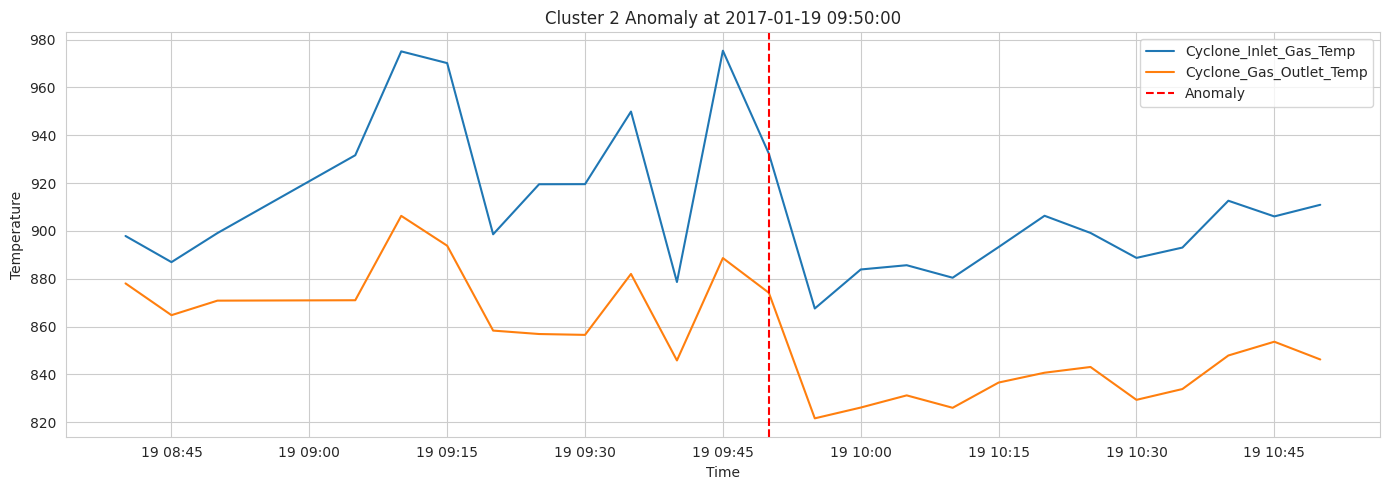

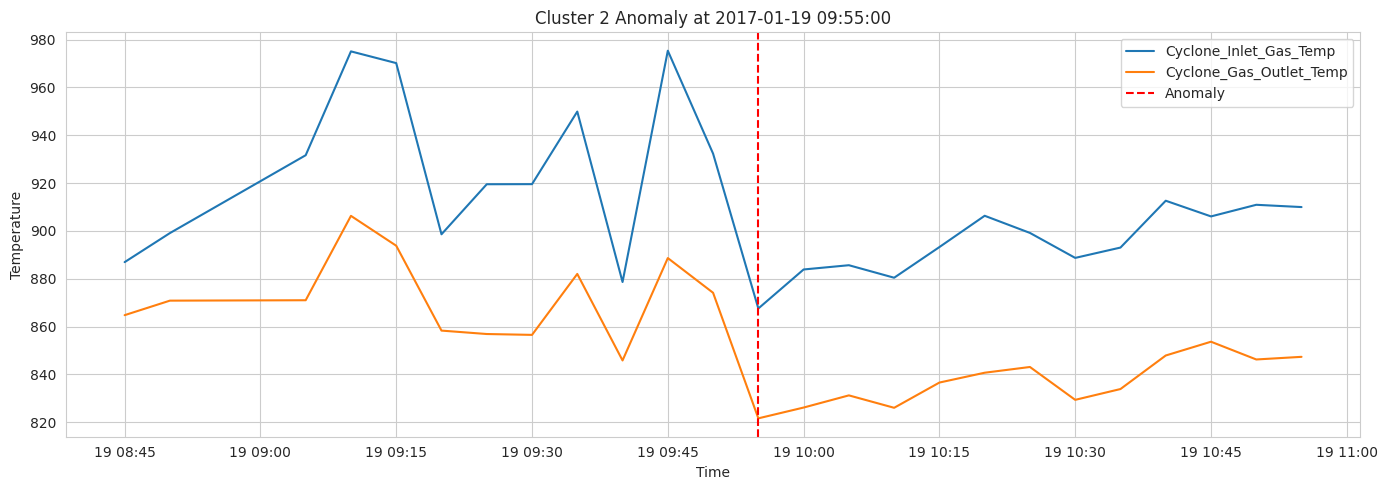

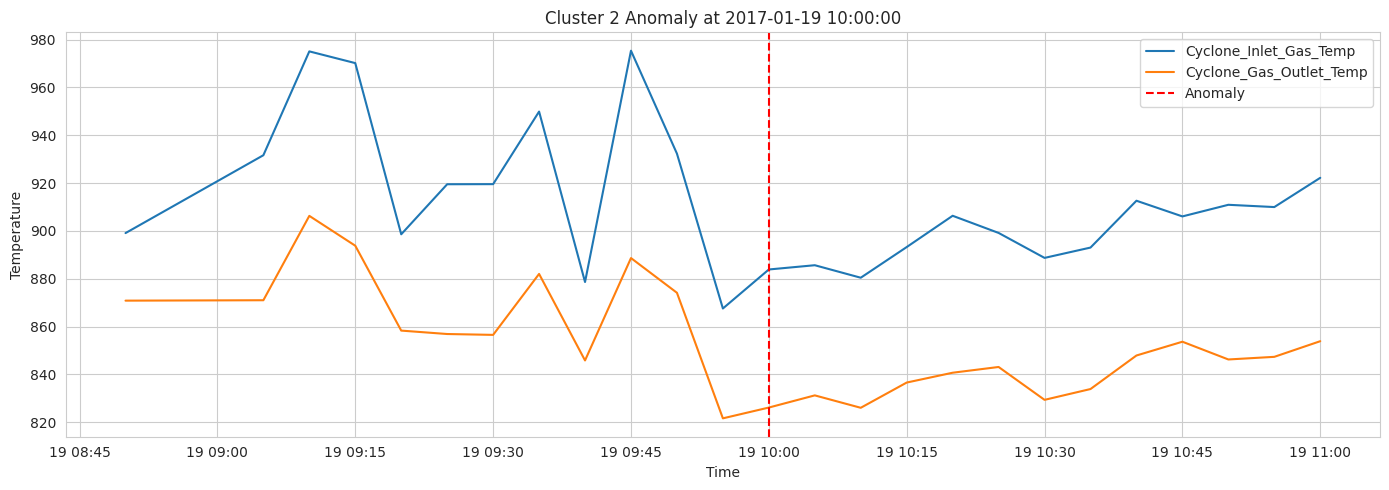

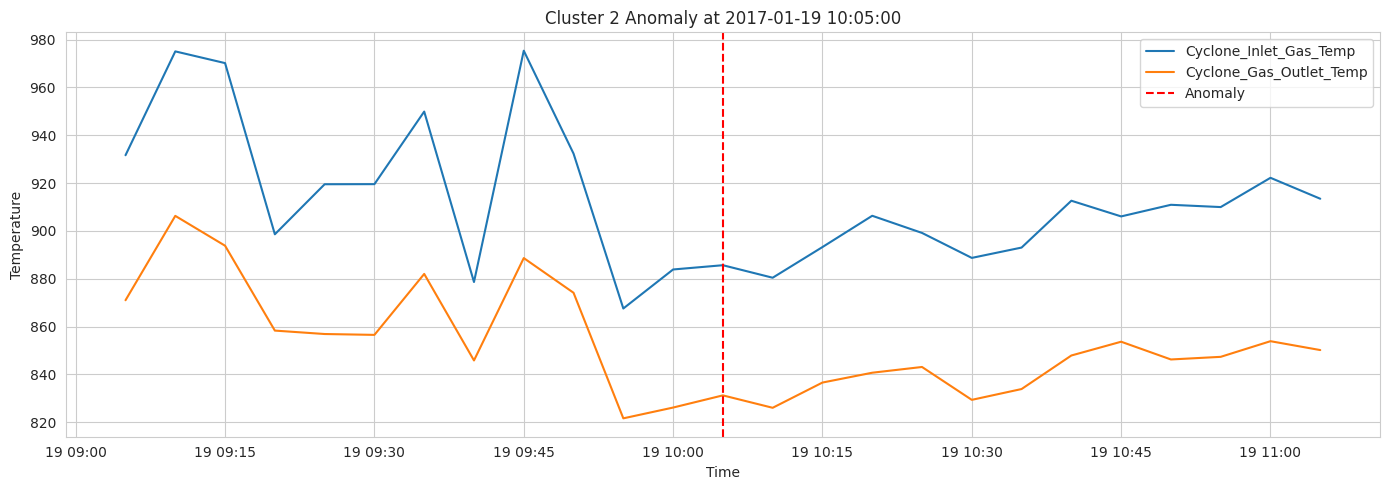

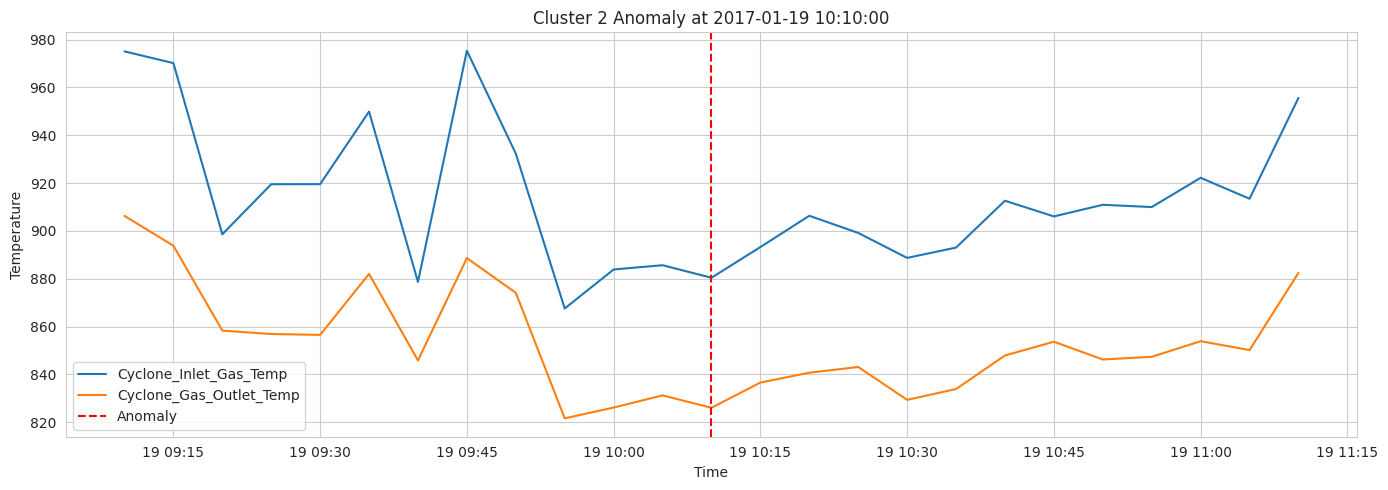

✅ Selected anomalies visualized and saved in Task1/plots/


In [ ]:
import matplotlib.pyplot as plt

# Pick first 5 anomalies for illustration
selected_anomalies = anomalies_df.head(5)

for i, row in selected_anomalies.iterrows():
    t = row['time']
    cluster_id = row['cluster']

    # Take a window around the anomaly (±1 hour)
    window = 12  # 12 steps = 1 hour
    start_idx = max(features.index.get_loc(t) - window, 0)
    end_idx = min(features.index.get_loc(t) + window, len(features)-1)
    sub_df = features.iloc[start_idx:end_idx+1]

    plt.figure(figsize=(14,5))
    for col in ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Gas_Outlet_Temp']:
        plt.plot(sub_df.index, sub_df[col], label=col)

    # Highlight anomaly
    plt.axvline(t, color='red', linestyle='--', label='Anomaly')
    plt.title(f"Cluster {cluster_id} Anomaly at {t}")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"Task1/plots/anomaly_{i}.png")
    plt.show()

print("✅ Selected anomalies visualized and saved in Task1/plots/")


# Part 5:- Short-Horizon Forecasting (Required)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Use active_df for forecasting
forecast_df = active_df[['Cyclone_Inlet_Gas_Temp']].copy()

# Create lag features (last 12 steps = 1 hour)
for lag in range(1, 13):
    forecast_df[f'lag_{lag}'] = forecast_df['Cyclone_Inlet_Gas_Temp'].shift(lag)

forecast_df = forecast_df.dropna()

# Split train/test (last 7 days as test)
split_idx = int(len(forecast_df) - 12*24*7)
train = forecast_df.iloc[:split_idx]
test = forecast_df.iloc[split_idx:]

X_train = train.drop(columns='Cyclone_Inlet_Gas_Temp')
y_train = train['Cyclone_Inlet_Gas_Temp']
X_test = test.drop(columns='Cyclone_Inlet_Gas_Temp')
y_test = test['Cyclone_Inlet_Gas_Temp']

# ---------- 1. Persistence baseline ----------
y_pred_persist = X_test['lag_1'].values

rmse_persist = np.sqrt(mean_squared_error(y_test, y_pred_persist))
mae_persist = mean_absolute_error(y_test, y_pred_persist)

print("Persistence Baseline -> RMSE:", rmse_persist, "MAE:", mae_persist)

# ---------- 2. RandomForest Regressor ----------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("RandomForest -> RMSE:", rmse_rf, "MAE:", mae_rf)

# Save forecast results
forecast_results = pd.DataFrame({
    'true': y_test,
    'pred_persist': y_pred_persist,
    'pred_rf': y_pred_rf
})
forecast_results.to_csv("Task1/outputs/forecasts.csv")
print("✅ Forecasts saved at Task1/outputs/forecasts.csv")


Persistence Baseline -> RMSE: 14.523918148622872 MAE: 10.862395833333332
RandomForest -> RMSE: 9.021510442404352 MAE: 6.870962006210399
✅ Forecasts saved at Task1/outputs/forecasts.csv


# Part 6 — Insights & Observations


### 1. Shutdown Patterns
- Over the 3 years, the system experienced 1,813 shutdowns.
- The total downtime adds up to roughly 417,000 minutes (~290 days).
- Unusual readings often appear 10–30 minutes before a shutdown, which could serve as early warning signs.

### 2. Machine States (Clusters)
- Clusters 0 and 2 are the most common and reflect normal operation.
- Cluster 1 seems to capture periods when the machine is starting up or shutting down.
- Cluster 3 is rare and probably represents a high-load or degraded state. This cluster also tends to show more anomalies.

### 3. Anomalies
- There were 2,918 anomalies detected in total.
- Many anomalies are found in Cluster 3, suggesting instability in that state.
- Anomalies often occur alongside sudden spikes or drops in the inlet temperature or draft pressures.

### 4. Forecasting Takeaways
- The RandomForest model outperformed a simple persistence approach (RMSE 9.02 vs 14.52).
- Forecasting can be tricky around shutdowns or big operational changes, but short-term predictions are reliable enough for monitoring.

### 5. Practical Recommendations
- Monitor Cyclone_Inlet_Gas_Temp and draft readings; spikes or drops could signal potential issues.
- Investigate anomalies in Cluster 3 as they often precede problems.
- Use RandomForest forecasts for short-term maintenance planning and operator support.
- Collect more operational data to improve future clustering, anomaly detection, and forecasting.


# Save insights to Task1/outputs
with open("Task1/outputs/insights.md", "w") as f:
    f.write(insights_text)

print("✅ Insights saved at Task1/outputs/insights.md")


In [ ]:
# Path to your extracted Task1 folder
task1_path = "/content/Task1"  # Update this if your folder is elsewhere

# README content
readme_content = """# Task 1 — Cyclone Machine Data Analysis (Timeseries)

## Project Overview
This project performs a comprehensive analysis of 3 years of cyclone sensor data (≈370,000 records at 5-minute intervals). The goal is to clean and explore the data, detect shutdowns, segment machine states, identify anomalies, perform short-term forecasting, and provide actionable insights.

## Folder Structure

Task1/
│
├── data/
│   └── cleaned_cyclone.csv          # Cleaned input data
│
├── outputs/
│   ├── shutdown_periods.csv         # Detected shutdown events
│   ├── anomalous_periods.csv        # Contextual anomalies with metadata
│   ├── clusters_summary.csv         # Summary statistics of machine states
│   ├── forecasts.csv                # True vs predicted values for forecasting
│   └── insights.md                  # Human-readable insights and recommendations
│
├── plots/
│   ├── year_with_shutdowns.png      # Visualization of shutdown periods
│   ├── cluster_distributions.png    # Cluster behavior summary plot
│   ├── anomalies_plot1.png          # Example anomaly visualizations
│   └── ... (other PNGs generated)
│
├── task1_analysis.ipynb             # Jupyter Notebook with full code
└── README.md                         # This file

## Steps to Run the Notebook

1. Upload `data.xlsx` (or `data.csv`) to the Colab environment if not already present.
2. Open `task1_analysis.ipynb` in Colab.
3. Run all cells sequentially:
   - Data loading and cleaning
   - Exploratory data analysis
   - Shutdown / idle period detection
   - Machine state clustering
   - Contextual anomaly detection
   - Short-horizon forecasting
   - Insights & storytelling
4. All outputs (CSV files, plots, insights) are automatically saved in the `outputs/` and `plots/` folders.

## Deliverables

- **Cleaned Data:** `data/cleaned_cyclone.csv`
- **Shutdown Events:** `outputs/shutdown_periods.csv`
- **Anomalies:** `outputs/anomalous_periods.csv`
- **Cluster Summary:** `outputs/clusters_summary.csv`
- **Forecasts:** `outputs/forecasts.csv`
- **Visualizations:** `plots/*.png`
- **Insights:** `outputs/insights.md`
- **Notebook:** `task1_analysis.ipynb`

## Notes

- All analysis uses 5-minute interval time series with interpolated missing values and corrected outliers.
- Shutdown periods and anomalies are detected programmatically using threshold-based and statistical methods.
- Machine states are clustered using KMeans on standardized features.
- Forecasting uses RandomForest regression for short-term 1-hour ahead prediction.
"""

# Save README.md in Task1 folder
with open(f"{task1_path}/README.md", "w") as f:
    f.write(readme_content)

print("✅ README.md added to Task1 folder")


✅ README.md added to Task1 folder
